In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
%matplotlib inline 

In [2]:
df = pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [4]:
df.tail()

,Weight,Height
18,76,150
19,87,167
20,45,129
21,56,140
22,72,160


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [6]:
df.describe

<bound method NDFrame.describe of     Weight  Height
0       45     120
1       58     135
2       48     123
3       60     145
4       70     160
5       78     162
6       80     163
7       90     175
8       95     182
9       78     170
10      82     176
11      95     182
12     105     175
13     100     183
14      85     170
15      78     177
16      50     140
17      65     159
18      76     150
19      87     167
20      45     129
21      56     140
22      72     160>

In [7]:
df.shape

(23, 2)

In [8]:
df.size

46

Text(0, 0.5, 'Height')

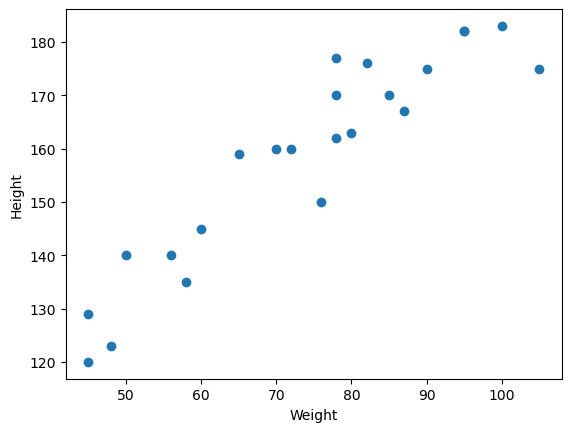

In [9]:
# scatter plot 
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [10]:
#finding correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


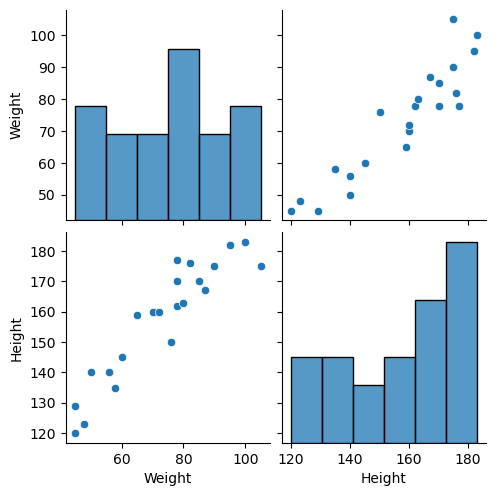

In [11]:
#Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [12]:
#step-1 # Independent and dependent features
x = df[['Weight']] # Note - make sure your independent Feature should be a dataFrame or 2D array
y = df['Height'] #Dependent feature can be Series form or 1D array 
# type(x) # DataFrame
# type(y) #Series
# type(df) #DataFrame

In [13]:
x_Series = df['Weight']
np.array(x_Series).shape

(23,)

In [14]:
## Train Test Split 
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [16]:
x_train.shape

(17, 1)

In [17]:
## Standardization - apply Z test/Z score - mean = 0 and standard deviation = 1
from sklearn.preprocessing import StandardScaler

In [18]:
#we have to apply standardization on input feature
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

In [162]:
#we use x train mean and standard deviation to transform - x_test
x_test = scaler.transform(x_test)
x_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [163]:
#Apply "Linear Regression
from sklearn.linear_model import LinearRegression

In [168]:
regression = LinearRegression(n_jobs=-1)

In [169]:
regression.fit(x_train,y_train)

LinearRegression(n_jobs=-1)

In [174]:
print('coefficient or Slope:', regression.coef_ )
print('Intercept:', regression.intercept_ )


coefficient or Slope: [17.2982057]
Intercept: 156.47058823529412


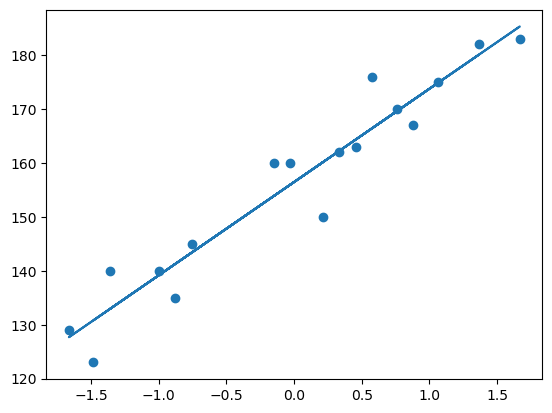

In [179]:
## Plot Training data plot best fit line 
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

### prediction of test data
1. predicted height output = intercept +coef_(Weights)
2. y_pred_test = 156.470 + 17.29 (x_test)

In [181]:
#Prediction for test data
y_pred = regression.predict(x_test)